In [1]:
from notebooks.consts import NOTEBOOK_PATH

SEEN_MODELS_FOLDER = NOTEBOOK_PATH / 'models' / 'SeenOligoModel'

In [2]:
import xgboost as xgb
import json

# 1. Reload your trained models
model_train_val = xgb.Booster()
model_train_val.load_model(str( SEEN_MODELS_FOLDER / "Model_Oligo_L2_TrainVal.json"))

model_all = xgb.Booster()
model_all.load_model(str(SEEN_MODELS_FOLDER / "Model_Oligo_L2_AllData.json"))

# 2. Recover the optimal features directly from the model!
best_feats = model_train_val.feature_names
print(f"Successfully recovered {len(best_feats)} optimal features!")

# 3. (Optional) Load your metrics back into a dictionary
with open(str(  SEEN_MODELS_FOLDER / "Model_Oligo_L2_TrainVal_metrics.json"), "r") as f:
    train_val_metrics = json.load(f)

# Recreate the dictionary the pipeline was supposed to return
models = {'model_train_val': model_train_val, 'model_all': model_all}

Successfully recovered 50 optimal features!


In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Assuming you have your data loaded: train_df, val_df, test_df, INHIBITION

def get_large_cohort_indices(df, group_cols, min_size=20):
    indices = []
    df_reset = df.reset_index(drop=True)
    for cohort, group in df_reset.groupby(group_cols):
        if len(group) >= min_size:
            indices.append(group.index.values)
    return indices

def evaluate_predictions(preds, y_true, eval_groups):
    """Calculates Spearman, MAE, RMSE, and Top K% Medians."""
    mae = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))

    spearmans, top_1_medians, top_5_medians = [], [], []
    for idxs in eval_groups:
        t_vals, p_vals = y_true[idxs], preds[idxs]

        corr, _ = spearmanr(t_vals, p_vals)
        if not np.isnan(corr): spearmans.append(corr)

        n = len(t_vals)
        k1, k5 = max(1, int(n * 0.01)), max(1, int(n * 0.05))

        if k5 > 0: top_5_medians.append(np.median(t_vals[np.argpartition(p_vals, -k5)[-k5:]]))
        if k1 > 0: top_1_medians.append(np.median(t_vals[np.argpartition(p_vals, -k1)[-k1:]]))

    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "Spearman": float(np.nanmedian(spearmans)) if spearmans else 0.0,
        "Top1_Inhib": float(np.nanmedian(top_1_medians)) if top_1_medians else 0.0,
        "Top5_Inhib": float(np.nanmedian(top_5_medians)) if top_5_medians else 0.0
    }

def evaluate_multiple_models(model_configs, train_df, val_df, test_df, target_col, eval_groups_dict):
    """
    Loads models, generates predictions once, and scores them across MULTIPLE grouping strategies.
    """
    y_train, y_val, y_test = train_df[target_col].values, val_df[target_col].values, test_df[target_col].values
    all_metrics = []

    print(f"Evaluating {len(model_configs)} configurations across {len(eval_groups_dict)} grouping strategies...")
    for model_name, config in model_configs.items():
        try:
            # 1. Handle Baseline
            if config.get('is_baseline', False):
                baseline_col = config['baseline_col']
                preds_train = train_df[baseline_col].values
                preds_val = val_df[baseline_col].values
                preds_test = test_df[baseline_col].values
                print(f"✅ Loaded Baseline: '{model_name}'")
            # 2. Handle XGBoost Models
            else:
                bst = xgb.Booster()
                bst.load_model(config['path'])
                model_features = bst.feature_names

                dtrain = xgb.DMatrix(train_df[model_features].values, feature_names=model_features)
                dval = xgb.DMatrix(val_df[model_features].values, feature_names=model_features)
                dtest = xgb.DMatrix(test_df[model_features].values, feature_names=model_features)

                preds_train = bst.predict(dtrain)
                preds_val = bst.predict(dval)
                preds_test = bst.predict(dtest)
                print(f"✅ Loaded XGBoost: '{model_name}'")

            test_split_name = "Test (Leaked)" if config.get('is_all_data', False) else "Test"

            # 3. Score across all Grouping Strategies dynamically
            for group_label, group_cols in eval_groups_dict.items():
                train_eval_idx = get_large_cohort_indices(train_df, group_cols)
                val_eval_idx = get_large_cohort_indices(val_df, group_cols)
                test_eval_idx = get_large_cohort_indices(test_df, group_cols)

                metrics_train = evaluate_predictions(preds_train, y_train, train_eval_idx)
                metrics_val = evaluate_predictions(preds_val, y_val, val_eval_idx)
                metrics_test = evaluate_predictions(preds_test, y_test, test_eval_idx)

                for split, metrics in [("Train", metrics_train), ("Validation", metrics_val), (test_split_name, metrics_test)]:
                    metrics["Model"] = model_name
                    metrics["Split"] = split
                    metrics["Grouping"] = group_label  # <-- Track which group generated this score
                    all_metrics.append(metrics)

        except Exception as e:
            print(f"❌ Failed to evaluate '{model_name}': {e}")

    df_results = pd.DataFrame(all_metrics)
    cols = ['Model', 'Split', 'Grouping', 'Spearman', 'Top1_Inhib', 'Top5_Inhib', 'MAE', 'RMSE']
    return df_results[cols]

In [6]:
from notebooks.models.SeenOligoModel.base_model import split_data
from notebooks.models.utility import load_and_validate_final_data

final_data, features = load_and_validate_final_data(version='oligo', load_competition=True)


[Loading features] finished in 64.4773s


In [7]:
# Default config
split_config = {
    'col': 'split',
    'train': 'train',
    'val': 'val',
    'test': 'test'
}

train_df, val_df, test_df = split_data(
    final_data,
    features,
    split_col=split_config["col"],
    train_val=split_config["train"],
    val_val=split_config["val"],
    test_val=split_config["test"],
)

Evaluating 14 configurations across 2 grouping strategies...
✅ Loaded Baseline: 'Competition (PFRED_PLS)'
✅ Loaded Baseline: 'Competition (PFRED_SVM)'
✅ Loaded Baseline: 'Competition (OW_Overall)'
✅ Loaded Baseline: 'Competition (OW_Tm)'
✅ Loaded Baseline: 'Competition (OW_Intra_Oligo)'
✅ Loaded Baseline: 'Competition (OW_Duplex)'
✅ Loaded Baseline: 'Competition (sfold_accessibility)'
✅ Loaded Baseline: 'Competition (miranda_score)'


/tmp/ipykernel_70076/3064285517.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(t_vals, p_vals)
/tmp/ipykernel_70076/3064285517.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(t_vals, p_vals)
/tmp/ipykernel_70076/3064285517.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(t_vals, p_vals)
/tmp/ipykernel_70076/3064285517.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(t_vals, p_vals)
/tmp/ipykernel_70076/3064285517.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(t_vals, p_vals)
/tmp/ipykernel_70076/3064285517.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = 

✅ Loaded Baseline: 'Competition (miranda_energy)'
✅ Loaded Baseline: 'Competition (oligo_ai_score)'
✅ Loaded XGBoost: 'L2 (Train+Val)'
✅ Loaded XGBoost: 'L2 (Train+Val) [CustomId]'
✅ Loaded XGBoost: 'L1 (Train+Val)'
✅ Loaded XGBoost: 'L1 (Train+Val) [CustomId]'

--- Summary Table ---


Spearman  \
Grouping                                     Cohort (Gene x Cell Line)   
Model                             Split                                  
Competition (OW_Duplex)           Test                          0.0052   
                                  Train                        -0.0798   
                                  Validation                   -0.1069   
Competition (OW_Intra_Oligo)      Test                          0.1794   
                                  Train                        -0.0022   
                                  Validation                   -0.0373   
Competition (OW_Overall)          Test                         -0.0513   
                                  Train                        -0.0873   
                                  Validation                   -0.0921   
Competition (OW_Tm)               Test                         -0.0102   
                                  Train                         0.0721   
                                  Validation                    0.1151   
Competition (PFRED_PLS)           Test                          0.0982   
                                  Train                         0.0332   
                                  Validation                    0.0743   
Competition (PFRED_SVM)           Test                          0.1216   
                                  Train                         0.0718   
                                  Validation                    0.1267   
Competition (miranda_energy)      Test                         -0.0001   
                                  Train                        -0.0741   
                                  Validation                   -0.0915   
Competition (miranda_score)       Test                         -0.0882   
                                  Train                        -0.1069   
                                  Validation                   -0.2309   
Competition (oligo_ai_score)      Test                          0.3854   
                                  Train                         0.3213   
                                  Validation                    0.3317   
Competition (sfold_accessibility) Test                          0.0918   
                                  Train                         0.0152   
                                  Validation                    0.0923   
L1 (Train+Val)                    Test                          0.3683   
                                  Train                         0.4488   
                                  Validation                    0.4719   
L1 (Train+Val) [CustomId]         Test                          0.3766   
                                  Train                         0.4556   
                                  Validation                    0.5172   
L2 (Train+Val)                    Test                          0.4116   
                                  Train                         0.4702   
                                  Validation                    0.5337   
L2 (Train+Val) [CustomId]         Test                          0.3768   
                                  Train                         0.4561   
                                  Validation                    0.5072   

                                                                     \
Grouping                                     Experiment (custom_id)   
Model                             Split                               
Competition (OW_Duplex)           Test                       0.1476   
                                  Train                      0.0332   
                                  Validation                -0.1031   
Competition (OW_Intra_Oligo)      Test                       0.1727   
                                  Train                      0.0522   
                                  Validation                -0.0050   
Competition (OW_Overall)          Test                       0.0903   
                     

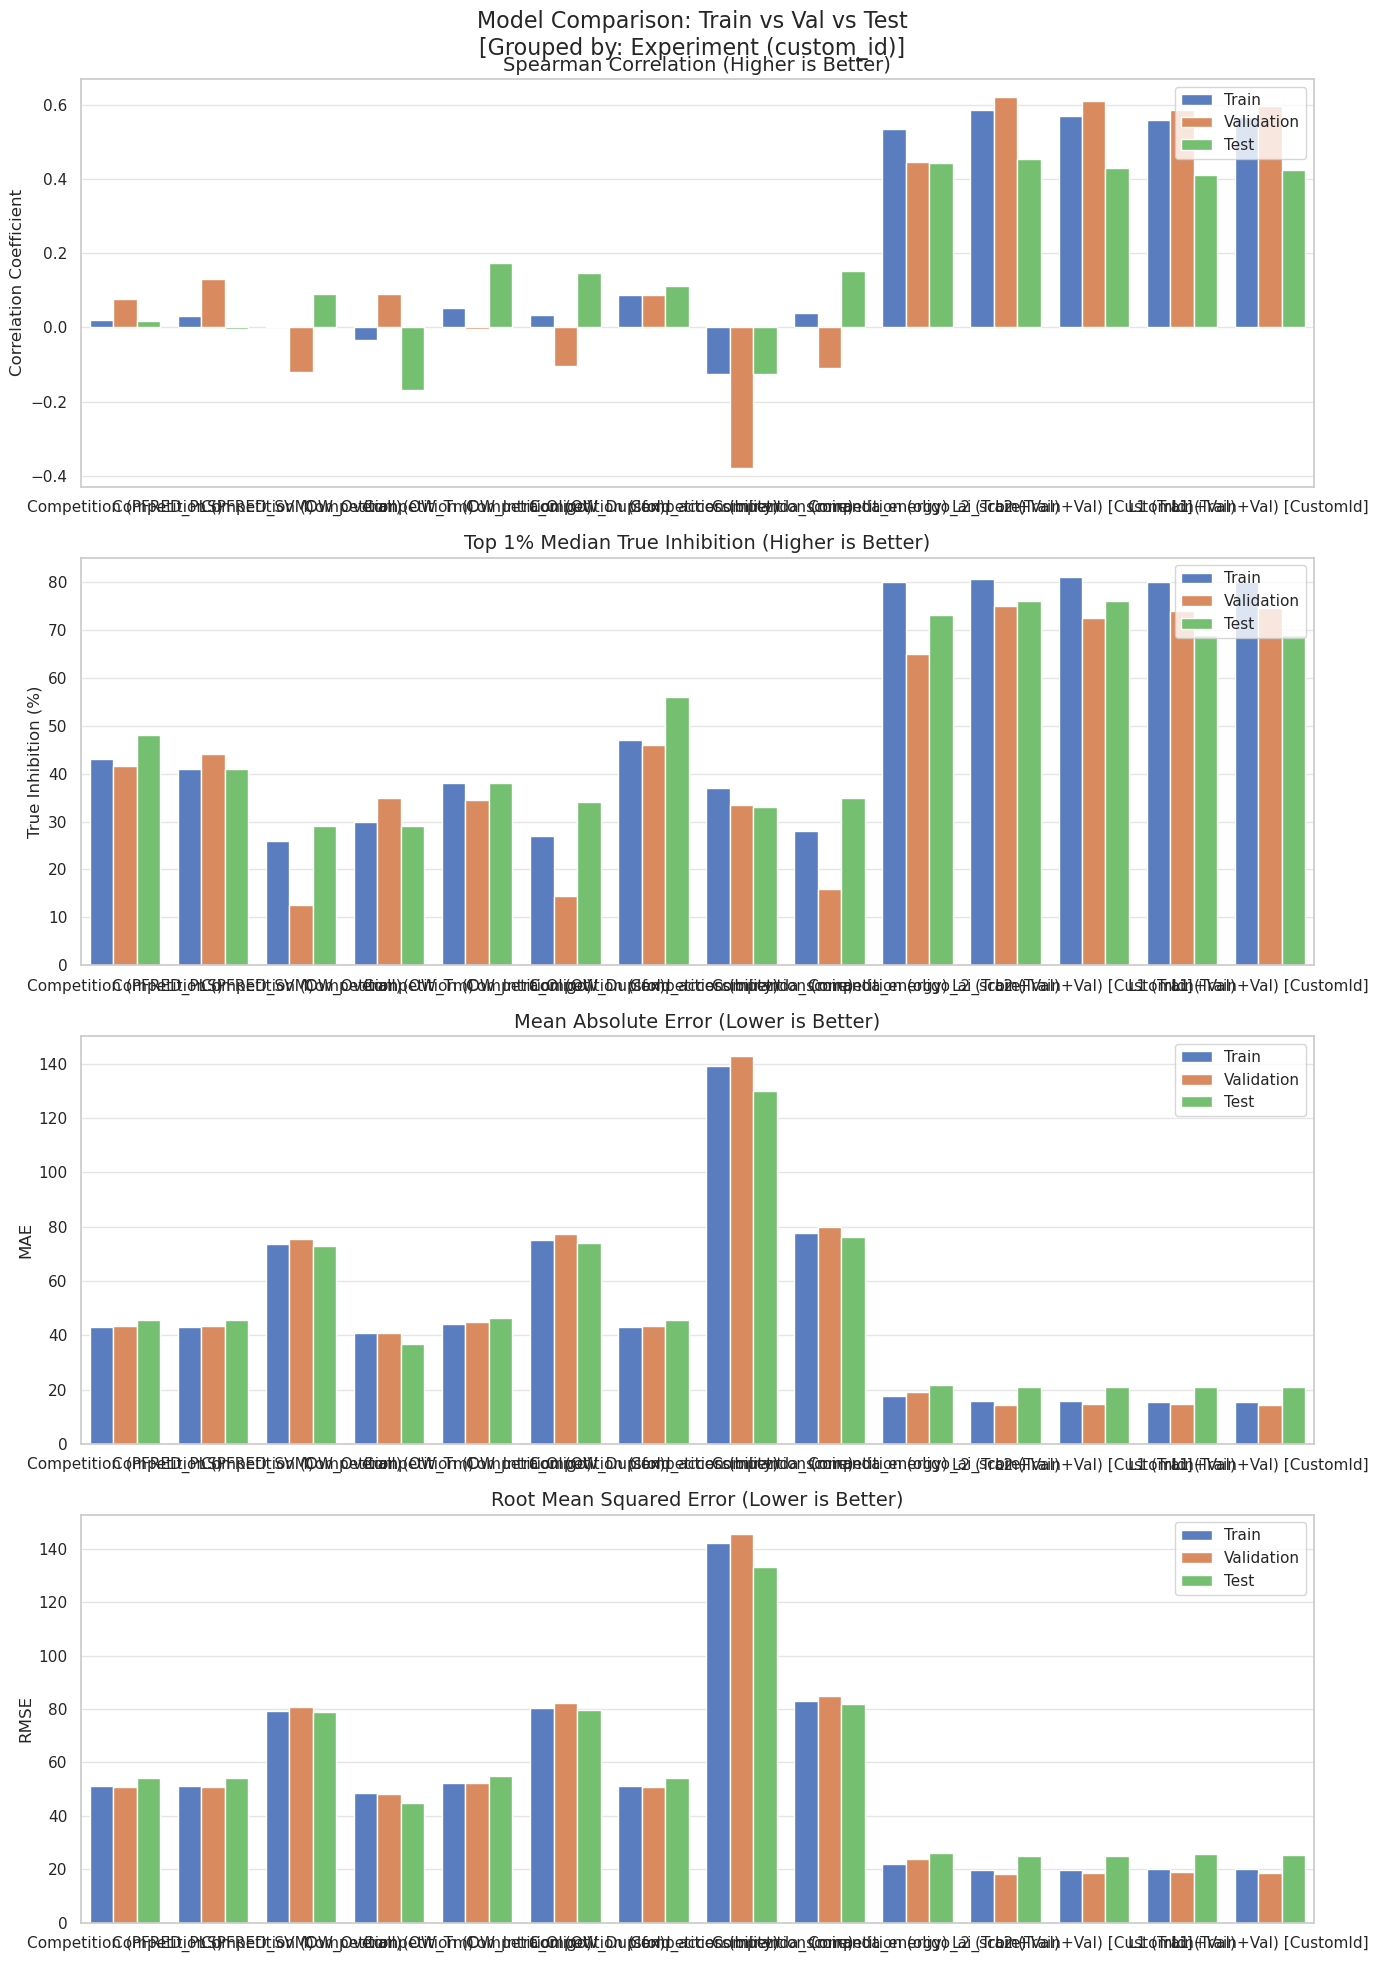

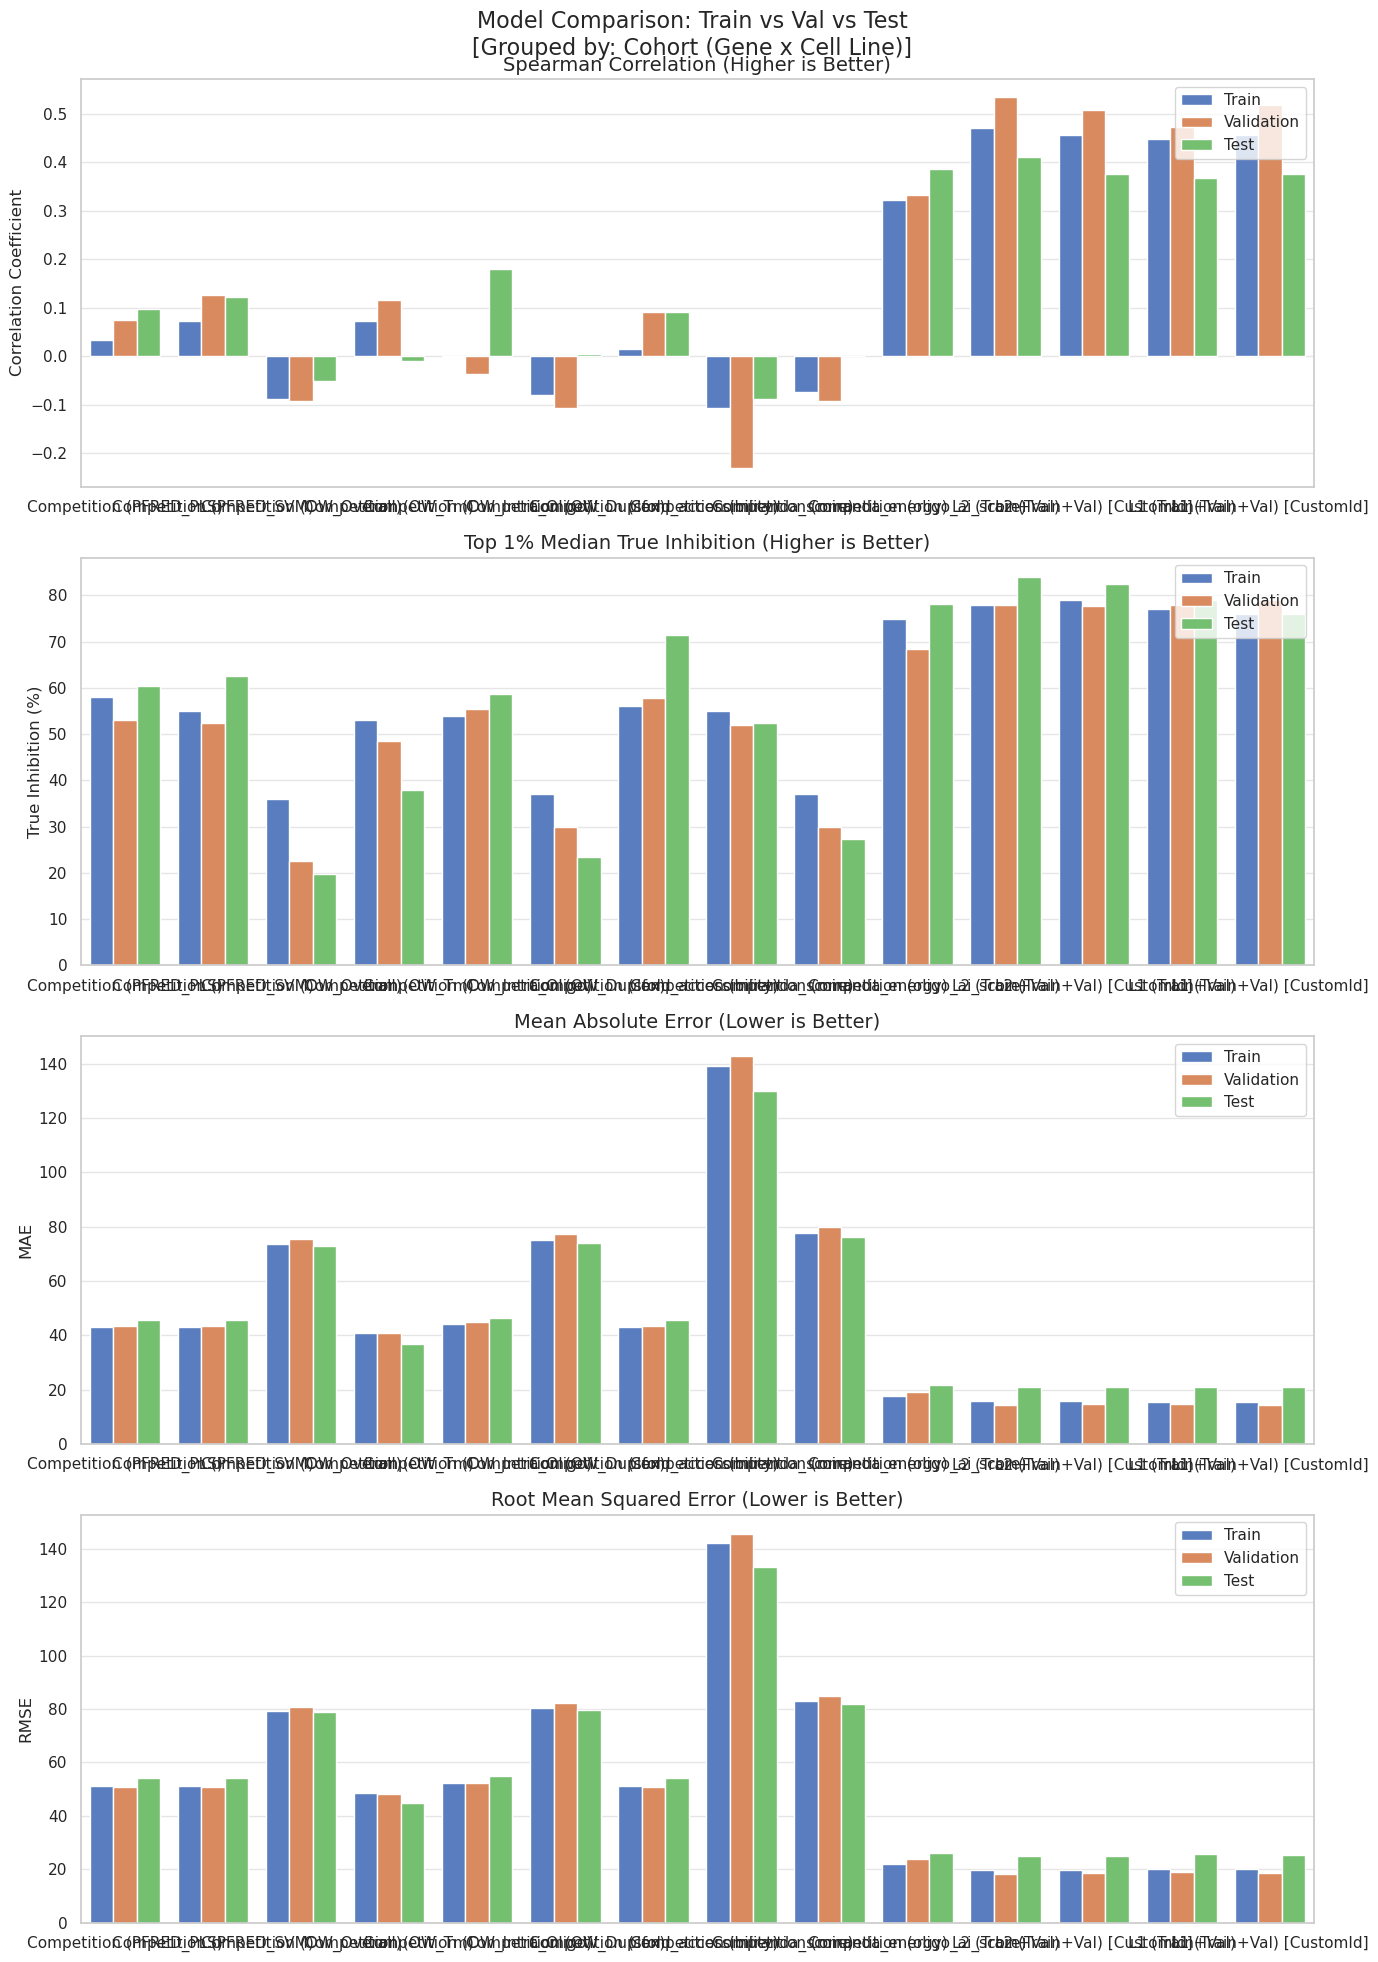

In [8]:
from tauso.data.consts import CANONICAL_GENE, CELL_LINE, INHIBITION

COMPETITION = [
    "PFRED_PLS",
    "PFRED_SVM",
    "OW_Overall",
    "OW_Tm",
    "OW_Intra_Oligo",
    "OW_Duplex",
    "sfold_accessibility",
    "miranda_score",
    "miranda_energy",
    "oligo_ai_score",
]

# 1. Dynamically create dictionary entries for all competition/baseline features
MODELS_TO_COMPARE = {
    f"Competition ({col})": {
        "is_baseline": True,
        "baseline_col": col,
        "is_all_data": False
    } for col in COMPETITION
}

# 2. Add your trained XGBoost models to the dictionary
MODELS_TO_COMPARE.update({
    "L2 (Train+Val)": {
        "path": str(SEEN_MODELS_FOLDER / "Model_Oligo_L2_TrainVal.json"),
        "is_all_data": False
    },
    "L2 (Train+Val) [CustomId]": {
    "path": str(SEEN_MODELS_FOLDER / "Model_Oligo_L2_CustomId_TrainVal.json"),
    "is_all_data": False
    },
    "L1 (Train+Val)": {
    "path": str(SEEN_MODELS_FOLDER / "Model_Oligo_L1_TrainVal.json"),
    "is_all_data": False
    },
    "L1 (Train+Val) [CustomId]": {
    "path": str(SEEN_MODELS_FOLDER / "Model_Oligo_L1_CustomId_TrainVal.json"),
    "is_all_data": False
    },
    # "L1 (Train+Val)": {
    #     "path": str(SEEN_MODELS_FOLDER / "Model_Oligo_L1_TrainVal.json"),
    #     "is_all_data": False
    # },
    # "L2 (All Data)": {
    #     "path": str(SEEN_MODELS_FOLDER / "Model_Oligo_L2_AllData.json"),
    #     "is_all_data": True
    # },
})


# Define the multiple groupings you want to track
EVAL_GROUPS = {
    'Experiment (custom_id)': 'custom_id',
    'Cohort (Gene x Cell Line)': [CANONICAL_GENE, CELL_LINE]
}

# Run Unified Evaluation
df_comparison = evaluate_multiple_models(
    model_configs=MODELS_TO_COMPARE,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    target_col=INHIBITION,
    eval_groups_dict=EVAL_GROUPS
)

print("\n--- Summary Table ---")
display(df_comparison.pivot(
    index=['Model', 'Split'],
    columns='Grouping',
    values=['Spearman', 'Top1_Inhib', 'Top5_Inhib','MAE', 'RMSE']
).round(4))

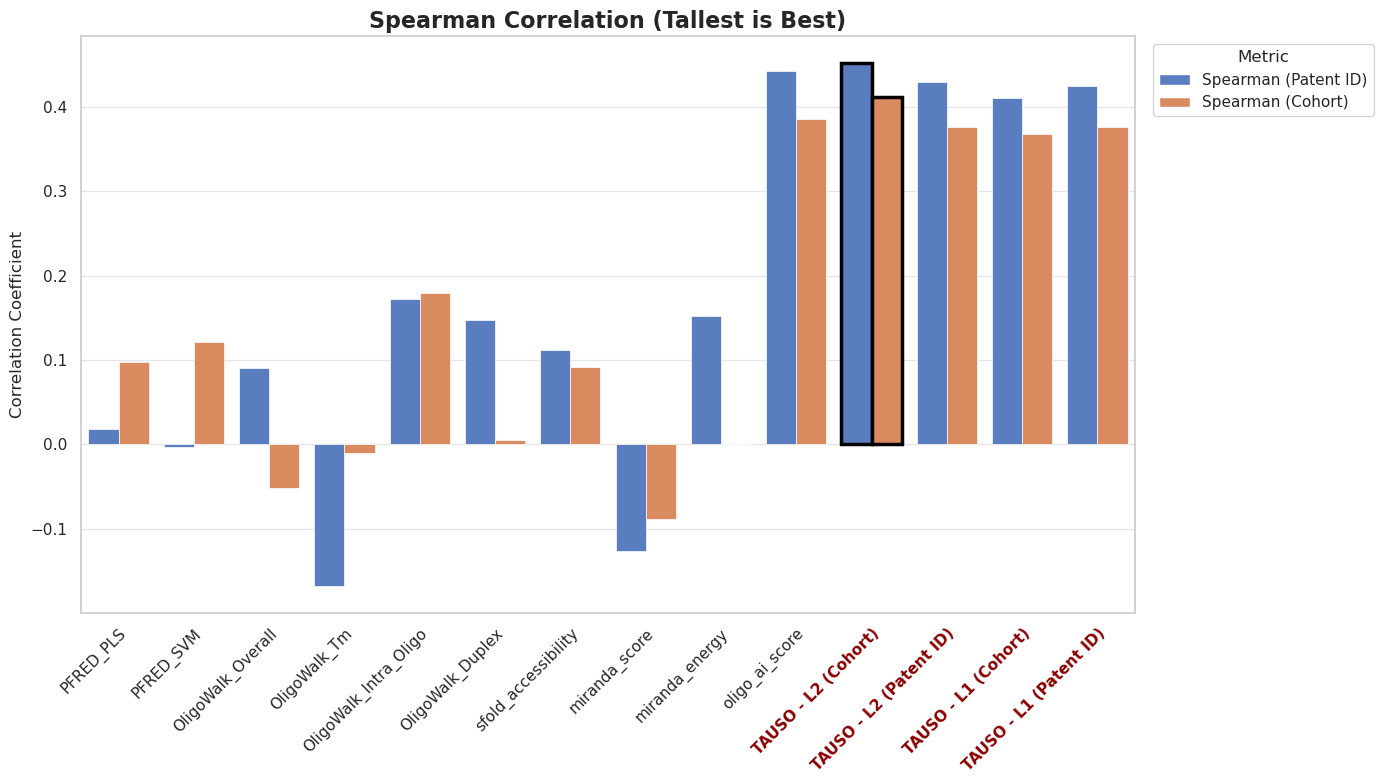

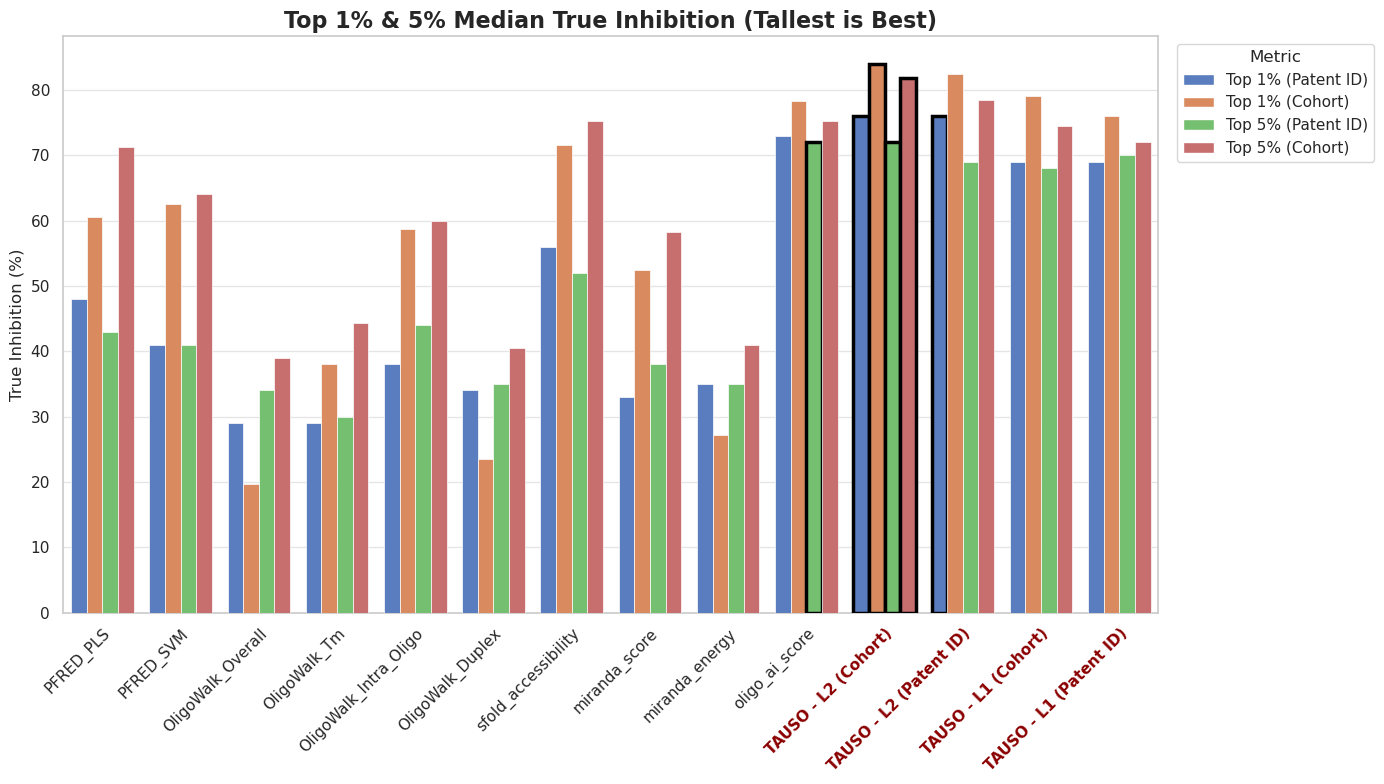

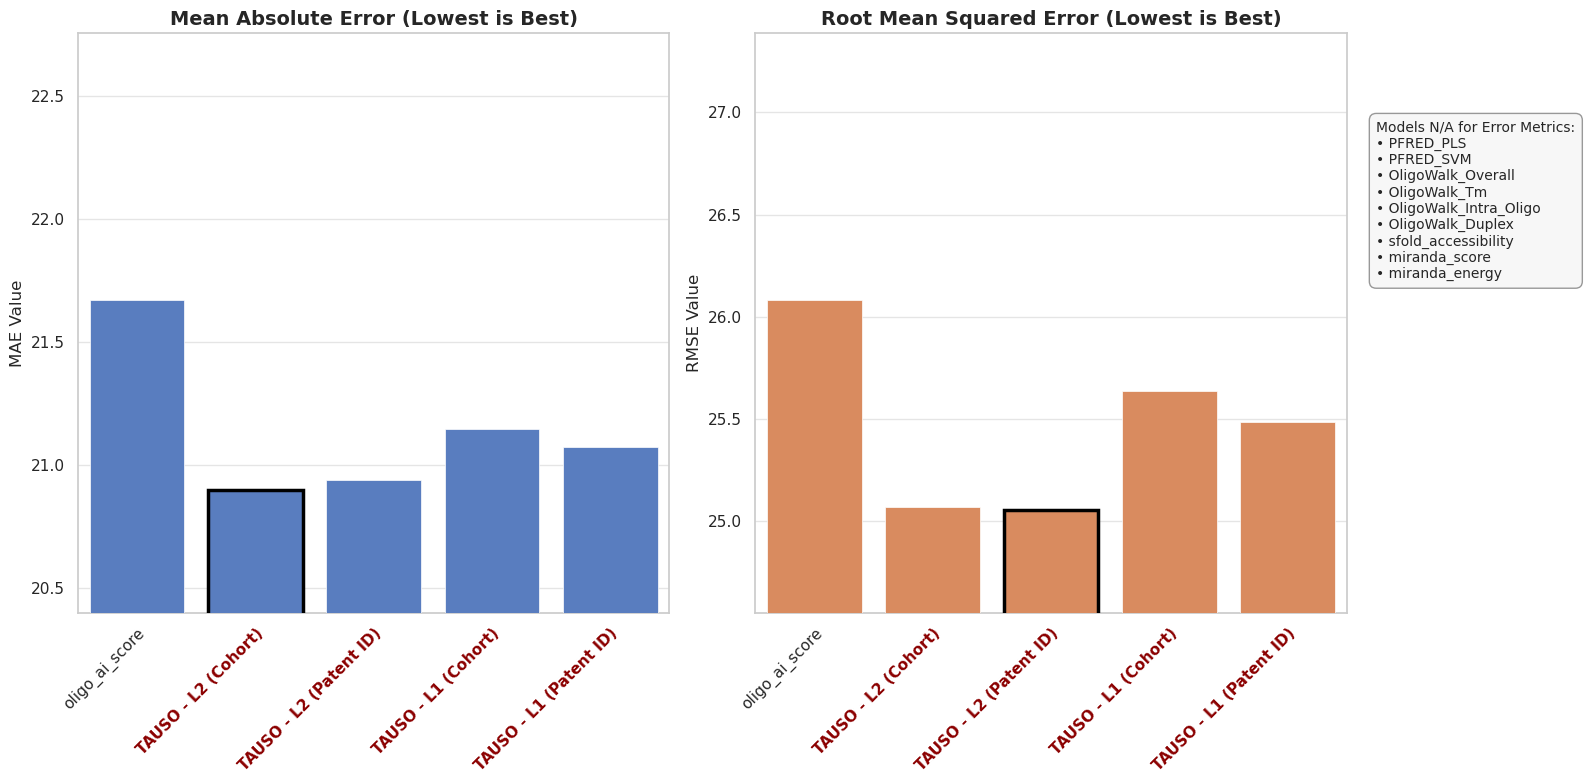

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def highlight_best_bars(ax, df_plot, x_col, hue_col, val_col, hue_order, min_is_best=False):
    """
    Strictly matches each bar to its specific hue group to apply the black highlight border.
    """
    n_models = len(ax.get_xticks())

    best_vals_per_hue = []
    for hue_val in hue_order:
        subset = df_plot[df_plot[hue_col] == hue_val][val_col].dropna()
        if not subset.empty:
            best_val = subset.min() if min_is_best else subset.max()
            best_vals_per_hue.append(best_val)
        else:
            best_vals_per_hue.append(np.nan)

    for i, patch in enumerate(ax.patches):
        h = patch.get_height()
        if pd.isna(h) or h == 0:
            continue

        hue_idx = i // n_models
        if hue_idx >= len(best_vals_per_hue):
            continue

        best_val_for_this_hue = best_vals_per_hue[hue_idx]

        if np.isclose(h, best_val_for_this_hue, rtol=1e-5):
            patch.set_edgecolor('black')
            patch.set_linewidth(2.5)
            patch.set_zorder(3)
        else:
            patch.set_edgecolor('white')
            patch.set_linewidth(0.5)
            patch.set_zorder(3)

        patch.set_alpha(1.0)

def format_xaxis(ax):
    """Helper to rotate labels and highlight the custom TAUSO models."""
    ax.set_xlabel('')
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    for label in ax.get_xticklabels():
        if 'TAUSO' in label.get_text():
            label.set_fontweight('bold')
            label.set_color('#8B0000')

def plot_separated_comparisons(df):
    """Plots 3 separate figures, splitting Error Metrics for independent scaling."""

    df_filtered = df[df['Split'] == "Test"].copy()

    # --- Clean up model names ---
    df_filtered['Model'] = df_filtered['Model'].str.replace(r'^Competition \((.*)\)$', r'\1', regex=True)
    df_filtered['Model'] = df_filtered['Model'].str.replace('OW_', 'OligoWalk_', regex=False)

    tauso_rename_map = {
        "L1 (Train+Val)": "TAUSO - L1 (Cohort)",
        "L1 (Train+Val) [CustomId]": "TAUSO - L1 (Patent ID)",
        "L2 (Train+Val)": "TAUSO - L2 (Cohort)",
        "L2 (Train+Val) [CustomId]": "TAUSO - L2 (Patent ID)"
    }
    df_filtered['Model'] = df_filtered['Model'].replace(tauso_rename_map)

    df_melted = df_filtered.melt(
        id_vars=['Model', 'Grouping'],
        value_vars=['Spearman', 'Top1_Inhib', 'Top5_Inhib', 'MAE', 'RMSE'],
        var_name='Metric',
        value_name='Value'
    )

    # Mask out invalid MAE/RMSE comparisons
    def is_valid_error_model(model_name):
        name_lower = model_name.lower()
        return 'oligo_ai' in name_lower or 'tauso' in name_lower

    invalid_error_mask = df_melted['Metric'].isin(['MAE', 'RMSE']) & (~df_melted['Model'].apply(is_valid_error_model))
    df_melted.loc[invalid_error_mask, 'Value'] = np.nan

    # Create Metric_Group and rename the labels
    df_melted['Metric_Group'] = df_melted['Metric'] + " [" + df_melted['Grouping'] + "]"

    legend_rename_map = {
        "Spearman [Experiment (custom_id)]": "Spearman (Patent ID)",
        "Spearman [Cohort (Gene x Cell Line)]": "Spearman (Cohort)",
        "Top1_Inhib [Experiment (custom_id)]": "Top 1% (Patent ID)",
        "Top1_Inhib [Cohort (Gene x Cell Line)]": "Top 1% (Cohort)",
        "Top5_Inhib [Experiment (custom_id)]": "Top 5% (Patent ID)",
        "Top5_Inhib [Cohort (Gene x Cell Line)]": "Top 5% (Cohort)"
    }
    df_melted['Metric_Group'] = df_melted['Metric_Group'].replace(legend_rename_map)

    sns.set_theme(style="whitegrid", palette="muted")
    model_order = df_melted['Model'].unique()

    valid_error_models = [m for m in model_order if is_valid_error_model(m)]
    invalid_error_models = [m for m in model_order if not is_valid_error_model(m)]

    # ---------------------------------------------------------
    # Plot 1: Spearman
    # ---------------------------------------------------------
    fig1, ax1 = plt.subplots(figsize=(14, 8))
    corr_data = df_melted[df_melted['Metric'] == 'Spearman']
    hue_order_1 = ["Spearman (Patent ID)", "Spearman (Cohort)"]

    sns.barplot(data=corr_data, x='Model', y='Value', hue='Metric_Group',
                hue_order=hue_order_1, order=model_order, ax=ax1)

    ax1.set_title('Spearman Correlation (Tallest is Best)', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Correlation Coefficient')
    ax1.legend(loc='upper left', bbox_to_anchor=(1.01, 1), title="Metric")
    highlight_best_bars(ax1, corr_data, 'Model', 'Metric_Group', 'Value', hue_order_1, min_is_best=False)
    format_xaxis(ax1)
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # Plot 2: Top 1% and Top 5%
    # ---------------------------------------------------------
    fig2, ax2 = plt.subplots(figsize=(14, 8))
    top_data = df_melted[df_melted['Metric'].isin(['Top1_Inhib', 'Top5_Inhib'])]
    hue_order_2 = ["Top 1% (Patent ID)", "Top 1% (Cohort)", "Top 5% (Patent ID)", "Top 5% (Cohort)"]

    sns.barplot(data=top_data, x='Model', y='Value', hue='Metric_Group',
                hue_order=hue_order_2, order=model_order, ax=ax2)

    ax2.set_title('Top 1% & 5% Median True Inhibition (Tallest is Best)', fontsize=16, fontweight='bold')
    ax2.set_ylabel('True Inhibition (%)')
    ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1), title="Metric")
    highlight_best_bars(ax2, top_data, 'Model', 'Metric_Group', 'Value', hue_order_2, min_is_best=False)
    format_xaxis(ax2)
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # Plot 3: MAE and RMSE (Side-by-side for independent scales)
    # ---------------------------------------------------------
    fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(16, 8))
    error_data = df_melted[df_melted['Metric'].isin(['MAE', 'RMSE'])].drop_duplicates(subset=['Model', 'Metric'])
    palette = sns.color_palette("muted")

    # --- 3A: MAE Plot ---
    mae_data = error_data[error_data['Metric'] == 'MAE'].dropna(subset=['Value'])
    sns.barplot(data=mae_data, x='Model', y='Value', hue='Metric', hue_order=['MAE'],
                order=valid_error_models, palette=[palette[0]], ax=ax3a)

    # Zoom tightly around the MAE values
    y_floor_mae = max(0, mae_data['Value'].min() - 0.5)
    ax3a.set_ylim(bottom=y_floor_mae)

    ax3a.set_title('Mean Absolute Error (Lowest is Best)', fontsize=14, fontweight='bold')
    ax3a.set_ylabel('MAE Value')
    ax3a.get_legend().remove() # Redundant since title specifies metric
    highlight_best_bars(ax3a, mae_data, 'Model', 'Metric', 'Value', ['MAE'], min_is_best=True)
    format_xaxis(ax3a)

    # --- 3B: RMSE Plot ---
    rmse_data = error_data[error_data['Metric'] == 'RMSE'].dropna(subset=['Value'])
    sns.barplot(data=rmse_data, x='Model', y='Value', hue='Metric', hue_order=['RMSE'],
                order=valid_error_models, palette=[palette[1]], ax=ax3b)

    # Zoom tightly around the RMSE values
    y_floor_rmse = max(0, rmse_data['Value'].min() - 0.5)
    ax3b.set_ylim(bottom=y_floor_rmse)

    ax3b.set_title('Root Mean Squared Error (Lowest is Best)', fontsize=14, fontweight='bold')
    ax3b.set_ylabel('RMSE Value')
    ax3b.get_legend().remove() # Redundant since title specifies metric
    highlight_best_bars(ax3b, rmse_data, 'Model', 'Metric', 'Value', ['RMSE'], min_is_best=True)
    format_xaxis(ax3b)

    # Models N/A text box appended to the right of the RMSE plot
    na_text = "Models N/A for Error Metrics:\n" + "\n".join([f"• {m}" for m in invalid_error_models])
    ax3b.text(1.05, 0.85, na_text, transform=ax3b.transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='whitesmoke', edgecolor='gray', alpha=0.8))

    plt.tight_layout()
    plt.show()

# Run the plot
plot_separated_comparisons(df_comparison)

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker

def plot_modifications_separated_for_paper(df):
    # --- 1. Environmental Setup ---
    plt.style.use('default')
    sns.set_theme(style="whitegrid")

    # --- 2. Data Preparation ---
    df_plot = df[df['Split'] == 'Test'].copy()

    # Rename Groupings
    group_map = {'Experiment (custom_id)': 'Patent ID', 'Cohort (Gene x Cell Line)': 'Cohort'}
    df_plot['Grouping'] = df_plot['Grouping'].replace(group_map)

    # Shorten Modifications
    mod_map = {'MOE/5-methylcytosines/deoxy': "2'MOE", 'cEt/5-methylcytosines/deoxy': "cEt"}
    df_plot['Modification'] = df_plot['Modification'].replace(mod_map)

    # Clean Model Names
    df_plot['Model'] = df_plot['Model'].str.replace(r'^Competition \((.*)\)$', r'\1', regex=True)
    df_plot['Model'] = df_plot['Model'].str.replace('OW_', 'OligoWalk_', regex=False)

    tauso_rename = {
        "L1 (Train+Val)": "TAUSO - L1 (Cohort)",
        "L1 (Train+Val) [CustomId]": "TAUSO - L1 (Patent ID)",
        "L2 (Train+Val)": "TAUSO - L2 (Cohort)",
        "L2 (Train+Val) [CustomId]": "TAUSO - L2 (Patent ID)"
    }
    df_plot['Model'] = df_plot['Model'].replace(tauso_rename)
    df_plot['Spearman'] = df_plot['Spearman'].fillna(0)

    # --- 3. Color & Model Mapping ---
    color_dict = {
        "TAUSO - L1 (Patent ID)": "#084594", "TAUSO - L1 (Cohort)": "#084594",
        "TAUSO - L2 (Patent ID)": "#d94801", "TAUSO - L2 (Cohort)": "#d94801",
        "oligo_ai_score": "#238b45"
    }

    others = sorted([m for m in df_plot['Model'].unique() if m not in color_dict])
    grey_palette = sns.color_palette("Greys_r", n_colors=len(others) + 2)
    for i, m in enumerate(others):
        color_dict[m] = grey_palette[i]

    model_order = [
        "TAUSO - L1 (Patent ID)", "TAUSO - L1 (Cohort)",
        "TAUSO - L2 (Patent ID)", "TAUSO - L2 (Cohort)",
        "oligo_ai_score"
    ] + others

    mods = sorted(df_plot['Modification'].unique())

    # --- 4. Legend Construction ---
    legend_elements = [
        mpatches.Patch(facecolor='#555555', edgecolor='white', label='Metric: Patent ID (Solid)'),
        mpatches.Patch(facecolor='#555555', edgecolor='white', hatch='////', label='Metric: Cohort (Lined)'),
        mpatches.Patch(facecolor='none', edgecolor='black', linewidth=2, label='Highlight: Best in Category'),
        mpatches.Patch(facecolor='none', label=''),
        mpatches.Patch(facecolor='#084594', label='TAUSO L1 Family'),
        mpatches.Patch(facecolor='#d94801', label='TAUSO L2 Family'),
        mpatches.Patch(facecolor='#238b45', label='Oligo AI'),
    ]

    # --- 5. Generate a Separate Plot for Each Modification ---
    for mod in mods:
        # Standard paper-width figure
        fig, ax = plt.subplots(figsize=(16, 8))

        # Isolate data for this specific modification
        mod_df = df_plot[df_plot['Modification'] == mod]

        # Identify the absolute best performers for this modification to highlight them
        best_p = mod_df[mod_df['Grouping'] == 'Patent ID']['Spearman'].max()
        best_c = mod_df[mod_df['Grouping'] == 'Cohort']['Spearman'].max()

        # Layout math
        bar_width = 0.35
        inner_gap = 0.04
        unit_width = 1.0
        x_ticks = []

        for i, model in enumerate(model_order):
            x_center = i * unit_width
            x_ticks.append(x_center)

            # Retrieve values
            val_p_data = mod_df[(mod_df['Model'] == model) & (mod_df['Grouping'] == 'Patent ID')]['Spearman'].values
            val_c_data = mod_df[(mod_df['Model'] == model) & (mod_df['Grouping'] == 'Cohort')]['Spearman'].values

            v_p = val_p_data[0] if len(val_p_data) > 0 else 0
            v_c = val_c_data[0] if len(val_c_data) > 0 else 0
            color = color_dict[model]

            is_best_p = np.isclose(v_p, best_p, rtol=1e-5) if not pd.isna(best_p) else False
            is_best_c = np.isclose(v_c, best_c, rtol=1e-5) if not pd.isna(best_c) else False

            # Draw Patent ID Bar (Solid)
            ax.bar(x_center - (bar_width + inner_gap)/2, v_p, width=bar_width, color=color,
                   edgecolor='black' if is_best_p else 'white', linewidth=3 if is_best_p else 0.8)

            # Draw Cohort Bar (Hatched)
            ax.bar(x_center + (bar_width + inner_gap)/2, v_c, width=bar_width, color=color, hatch='////',
                   edgecolor='black' if is_best_c else 'white', linewidth=3 if is_best_c else 0.8)

        # --- 6. Formatting & Aesthetics ---
        # Apply X-axis labels directly
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(model_order, rotation=45, ha='right', fontsize=12, fontweight='bold')

        # Color the TAUSO labels on the X-axis red so they stand out
        for label in ax.get_xticklabels():
            if 'TAUSO' in label.get_text():
                label.set_color('#8B0000')

        # Y-Axis formatting
        ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
        ax.tick_params(axis='y', labelsize=12)
        ax.set_ylim(top=mod_df['Spearman'].max() + 0.1) # Dynamic top limit

        ax.set_title(f"Modification Performance: {mod} (Patent ID vs Cohort Spearman)", fontsize=18, fontweight='bold', pad=20)
        ax.set_ylabel('Spearman Correlation', fontsize=14, fontweight='bold')

        # Attach legend outside
        ax.legend(handles=legend_elements, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=11, frameon=True)

        plt.tight_layout()
        plt.show()

# Run the separated plots
plot_modifications_separated_for_paper(df_comparison_mod)

NameError: name 'df_comparison_mod' is not defined